In [7]:
import pandas as pd
import ast

In [8]:
df = pd.read_csv("./data/re_free_dataset.csv")

# Rare earth elements
rare_earths = ["Nd","Sm","Gd","Eu","Tb","Dy","Ho","Er","Pr","La","Ce","Y","Sc"]

def parse_elems(e):
    try: return ast.literal_eval(e)
    except: return []

df["elements_list"] = df["elements"].apply(parse_elems)

# RE-Free filter
df["is_re_free"] = df["elements_list"].apply(
    lambda x: not any(e in x for e in rare_earths)
)

In [9]:
df_pm = df[
    (df["energy_above_hull"] < 0.1) &
    (df["total_magnetization"] > 0.5) &
    (df["is_re_free"] == True)
].copy()

In [10]:
df_pm = df_pm.sort_values("total_magnetization", ascending=False)
df_pm.to_csv("./data/re_free_pm_candidates.csv", index=False)

In [11]:
print(f"Total fetched       : {len(df)}")
print(f"RE-Free PM candidates: {len(df_pm)}")
print(df_pm[["formula","total_magnetization","energy_above_hull",
             "crystal_system","density"]].to_string())

Total fetched       : 104
RE-Free PM candidates: 72
         formula  total_magnetization  energy_above_hull crystal_system    density
11    Ba3Fe26O41           256.235535           0.050177      Hexagonal   5.037862
0     Ba(Fe2O3)9           176.092134           0.073515      Hexagonal   5.025815
5       Ba2Fe2O5           140.000558           0.025427     Monoclinic   5.508228
7       Ba2Fe2O5           140.000083           0.000000     Monoclinic   5.439627
22     BaFe12O19           120.000133           0.055781      Hexagonal   5.009713
21     BaFe12O19           120.000105           0.055359      Hexagonal   5.011015
103    SrFe12O19           120.000088           0.081767      Hexagonal   4.824615
102    SrFe12O19           120.000063           0.072471      Hexagonal   4.847764
10     Ba2Fe6O11           120.000059           0.009605   Orthorhombic   4.626406
87   Sr18Fe18O47            85.999961           0.090147      Triclinic   4.905105
29       Fe24N11            78.0871

In [12]:
experimental = pd.DataFrame({
    "formula":    ["FeNi","MnAl","MnBi","BaFe12O19","SrFe12O19","FeCo"],
    "Tc_K":       [823,   650,   630,   723,         743,        1253 ],
    "Ms_T":       [1.59,  0.75,  0.78,  0.48,        0.46,       2.45 ],
    "Hc_kAm":     [200,   287,   880,   318,         265,        20   ],
    "BHmax_kJm3": [100,   56,    44,    45,          30,         10   ],
})

# Merge with DFT data
df_merged = df_pm.merge(experimental, on="formula", how="left")
df_merged.to_csv("./data/re_free_merged.csv", index=False)

print("Experimental data matched:")
print(df_merged[df_merged["Tc_K"].notna()][
    ["formula","total_magnetization","Tc_K","Ms_T","BHmax_kJm3"]
])

Experimental data matched:
      formula  total_magnetization   Tc_K  Ms_T  BHmax_kJm3
4   BaFe12O19           120.000133  723.0  0.48        45.0
5   BaFe12O19           120.000105  723.0  0.48        45.0
6   SrFe12O19           120.000088  743.0  0.46        30.0
7   SrFe12O19           120.000063  743.0  0.46        30.0
68       FeNi             3.257355  823.0  1.59       100.0
69       FeNi             3.165973  823.0  1.59       100.0
71       MnAl             1.921248  650.0  0.75        56.0


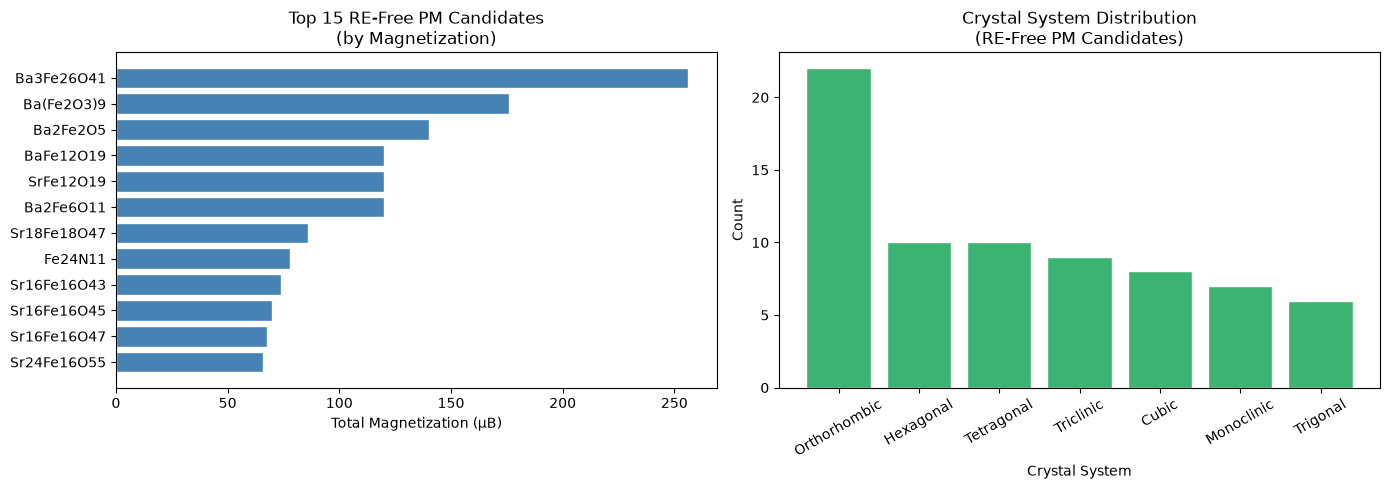

In [15]:
import matplotlib.pyplot as plt

# Top 15 by magnetization
top15 = df_pm.head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Top 15 Magnetization
axes[0].barh(top15["formula"], top15["total_magnetization"],
             color="steelblue", edgecolor="white")
axes[0].set_xlabel("Total Magnetization (μB)")
axes[0].set_title("Top 15 RE-Free PM Candidates\n(by Magnetization)")
axes[0].invert_yaxis()

# Plot 2 — Crystal System Distribution
crystal_counts = df_pm["crystal_system"].value_counts()
axes[1].bar(crystal_counts.index, crystal_counts.values,
            color="mediumseagreen", edgecolor="white")
axes[1].set_title("Crystal System Distribution\n(RE-Free PM Candidates)")
axes[1].set_xlabel("Crystal System")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig("./figure/re_free_plot.png", dpi=150)
plt.show()